In [19]:
import hashlib, random, os
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

ROOT = Path('/kaggle/input/datasets/puneet6060/intel-image-classification')
OUT = Path('/kaggle/working')
SEED = 42
IMG_SIZE = 128
BATCH = 64

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## 1. Исследование данных

### 1.1 Индекс всех файлов

Для каждого файла записываем расширение, формат и размер изображения, хеш содержимого (MD5) и признак повреждения. Так ищем повреждения и дубликаты.

In [20]:
PARTS = ('seg_train', 'seg_test', 'seg_pred')

def inspect_file(p):
    part = next((s for s in PARTS if s in p.parts), None)
    row = dict(path=str(p), part=part, ext=p.suffix.lower(),
               label=p.parent.name if part in PARTS[:2] else None,
               md5=hashlib.md5(p.read_bytes()).hexdigest(),
               w=None, h=None, mode=None, fmt=None, corrupt=False)
    try:
        with Image.open(p) as im:
            im.load()
            row.update(w=im.width, h=im.height, mode=im.mode, fmt=im.format)
    except Exception:
        row['corrupt'] = True
    return row

files = sorted(p for p in ROOT.rglob('*') if p.is_file())
with ThreadPoolExecutor(8) as pool:
    df = pd.DataFrame(list(tqdm(pool.map(inspect_file, files), total=len(files))))
df.to_csv(OUT / 'index_all.csv', index=False)
print(len(df))
df.head()

  0%|          | 0/24335 [00:00<?, ?it/s]

24335


,path,part,ext,label,md5,w,h,mode,fmt,corrupt
0,/kaggle/input/datasets/puneet6060/intel-image-...,seg_pred,.jpg,None,384ce7273f7ab374e83b1f0ac55da4c0,150,150,RGB,JPEG,False
1,/kaggle/input/datasets/puneet6060/intel-image-...,seg_pred,.jpg,None,ea751c5b2e9b03addef37f3ea180757e,150,150,RGB,JPEG,False
2,/kaggle/input/datasets/puneet6060/intel-image-...,seg_pred,.jpg,None,be95013e27d770dcda451c2e8034de6f,150,150,RGB,JPEG,False
3,/kaggle/input/datasets/puneet6060/intel-image-...,seg_pred,.jpg,None,230003393449086826c2a8e474ebd291,150,150,RGB,JPEG,False
4,/kaggle/input/datasets/puneet6060/intel-image-...,seg_pred,.jpg,None,aebae1cb7a0f4674013b82bb1e8d7f5f,150,150,RGB,JPEG,False


### 1.2 Число изображений и баланс классов

seg_pred (без меток): 7301


part,seg_test,seg_train,total,"share_train, %"
label,,,,
buildings,437,2191,2628,15.6
forest,474,2271,2745,16.2
glacier,553,2404,2957,17.1
mountain,525,2512,3037,17.9
sea,510,2274,2784,16.2
street,501,2382,2883,17.0


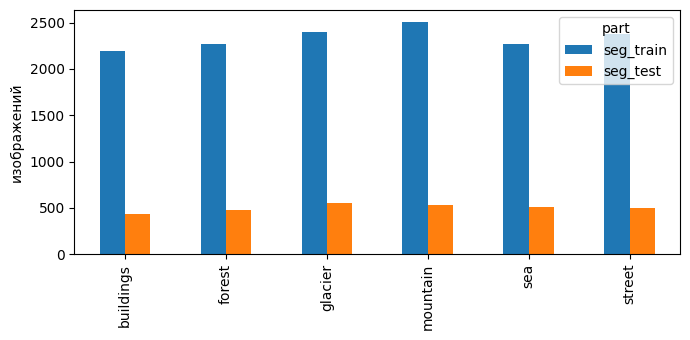

max/min в train: 1.15


In [21]:
lab = df[df.part.isin(PARTS[:2])]
counts = lab.pivot_table(index='label', columns='part', values='path', aggfunc='count')
counts['total'] = counts.sum(axis=1)
counts['share_train, %'] = (counts['seg_train'] / counts['seg_train'].sum() * 100).round(1)
print('seg_pred (без меток):', (df.part == 'seg_pred').sum())
display(counts)

fig, ax = plt.subplots(figsize=(7, 3.5))
counts[['seg_train', 'seg_test']].plot.bar(ax=ax)
ax.set_ylabel('изображений'); ax.set_xlabel('')
plt.tight_layout(); plt.show()
print('max/min в train:', round(counts.seg_train.max() / counts.seg_train.min(), 2))

### 1.3 Расширения, размеры, режимы, повреждённые файлы

ext
.jpg    24335
Name: count, dtype: int64

fmt
JPEG    24335
Name: count, dtype: int64

mode
RGB    24335
Name: count, dtype: int64



,count
size,
150x150,24267
150x113,7
150x108,3
150x131,3
150x149,3
150x143,3
150x135,3
150x111,3
150x144,3


повреждённых: 0


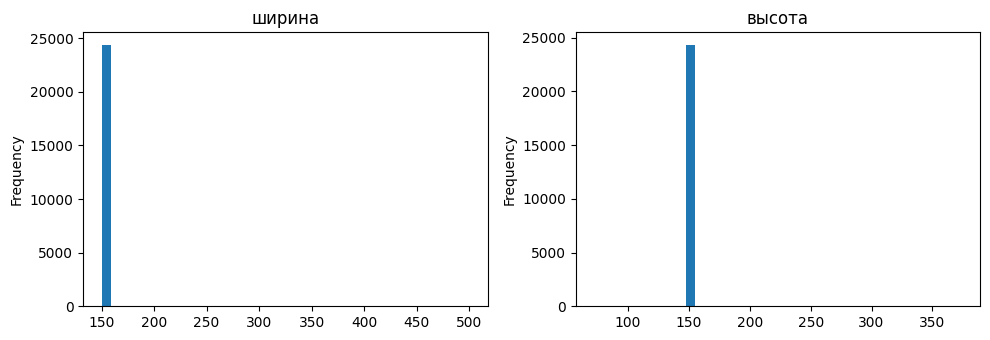

In [22]:
print(df.ext.value_counts(), end='\n\n')
print(df.fmt.value_counts(dropna=False), end='\n\n')
print(df['mode'].value_counts(dropna=False), end='\n\n')
sizes = df.assign(size=df.w.astype('Int64').astype(str) + 'x' + df.h.astype('Int64').astype(str))
display(sizes['size'].value_counts().head(10).to_frame('count'))
print('повреждённых:', df.corrupt.sum())

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df.w.plot.hist(bins=40, ax=ax[0], title='ширина'); df.h.plot.hist(bins=40, ax=ax[1], title='высота')
plt.tight_layout(); plt.show()

### 1.4 Полные дубликаты

In [23]:
g = df.groupby('md5')
df['dup_n'] = g.path.transform('size')
df['dup_labels'] = g.label.transform('nunique')
df['dup_parts'] = g.part.transform('nunique')
lab = df[df.part.isin(PARTS[:2])]

dups = df[df.dup_n > 1]
print('файлов в группах дубликатов:', len(dups), '| групп:', dups.md5.nunique())
print('групп с разными метками:', dups[dups.dup_labels > 1].md5.nunique())
print('групп, пересекающих train/test/pred:', dups[dups.dup_parts > 1].md5.nunique())
dups.sort_values('md5')[['md5', 'part', 'label', 'path']].head(10)

файлов в группах дубликатов: 94 | групп: 47
групп с разными метками: 13
групп, пересекающих train/test/pred: 27


,md5,part,label,path
5704,015d83aa90a3fac620bd1fd595a55a95,seg_pred,None,/kaggle/input/datasets/puneet6060/intel-image-...
20729,015d83aa90a3fac620bd1fd595a55a95,seg_train,sea,/kaggle/input/datasets/puneet6060/intel-image-...
21701,0b425690368e341777a1d5ee3aef3e1e,seg_train,sea,/kaggle/input/datasets/puneet6060/intel-image-...
20800,0b425690368e341777a1d5ee3aef3e1e,seg_train,sea,/kaggle/input/datasets/puneet6060/intel-image-...
18101,0e1ff2651ce5f2b2b435adc3704f5da8,seg_train,mountain,/kaggle/input/datasets/puneet6060/intel-image-...
16944,0e1ff2651ce5f2b2b435adc3704f5da8,seg_train,glacier,/kaggle/input/datasets/puneet6060/intel-image-...
11790,0f828d0b42199af7df469e9eada73f32,seg_train,buildings,/kaggle/input/datasets/puneet6060/intel-image-...
2517,0f828d0b42199af7df469e9eada73f32,seg_pred,None,/kaggle/input/datasets/puneet6060/intel-image-...
1111,157bfa252f9b4f5b8a57a7e815152c02,seg_pred,None,/kaggle/input/datasets/puneet6060/intel-image-...
17198,157bfa252f9b4f5b8a57a7e815152c02,seg_train,mountain,/kaggle/input/datasets/puneet6060/intel-image-...


### 1.5 Сводная таблица: классы, размеры, проблемы

In [24]:
def summarize(x):
    return pd.Series({
        'images': len(x),
        'corrupt': x.corrupt.sum(),
        'not_150x150': ((x.w != 150) | (x.h != 150)).sum() - x.corrupt.sum(),
        'min_wh': f'{int(x.w.min())}x{int(x.h.min())}',
        'max_wh': f'{int(x.w.max())}x{int(x.h.max())}',
        'non_RGB': (x['mode'] != 'RGB').sum() - x.corrupt.sum(),
        'dup_copies': (x.dup_n > 1).sum() - x[x.dup_n > 1].md5.nunique(),
        'label_conflict': (x.dup_labels > 1).sum(),
        'cross_part_dup': (x.dup_parts > 1).sum(),
    })

report = lab.groupby('label').apply(summarize)
report.loc['ВСЕГО'] = report.apply(lambda c: c.sum() if c.dtype != object else '')
report.to_csv(OUT / 'data_report.csv')
report

/tmp/ipykernel_48/3671487894.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  report = lab.groupby('label').apply(summarize)


,images,corrupt,not_150x150,min_wh,max_wh,non_RGB,dup_copies,label_conflict,cross_part_dup
label,,,,,,,,,
buildings,2628,0,1,150x124,150x150,0,0,5,6
forest,2745,0,9,150x108,150x150,0,2,0,2
glacier,2957,0,21,150x72,150x150,0,0,7,2
mountain,3037,0,19,150x81,150x150,0,0,8,8
sea,2784,0,4,150x113,150x150,0,1,1,7
street,2883,0,1,150x113,150x150,0,2,5,5
ВСЕГО,17034,0,55,,,0,5,26,30


### 1.6 Случайные примеры каждого класса

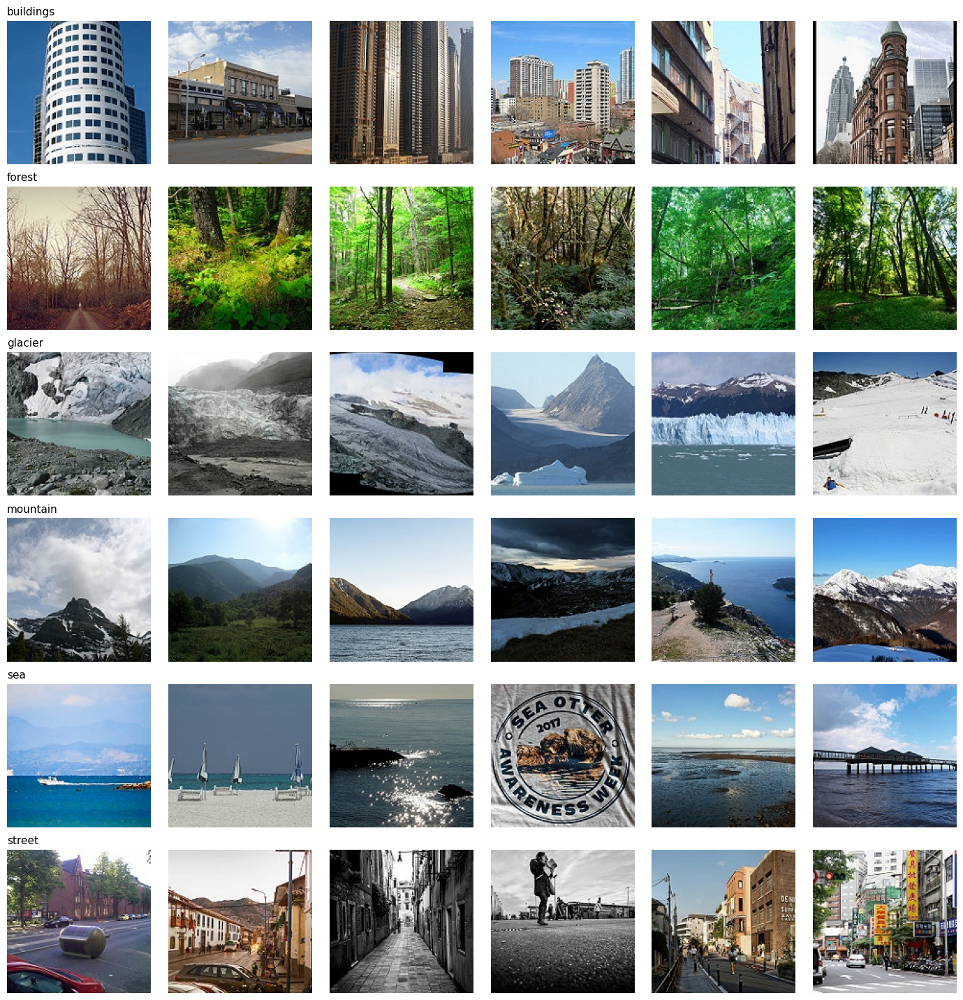

In [25]:
classes = sorted(lab.label.unique())
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(classes), 6, figsize=(14, 2.4 * len(classes)))
for i, c in enumerate(classes):
    sub = lab[(lab.label == c) & ~lab.corrupt]
    for j, p in enumerate(rng.choice(sub.path.values, 6, replace=False)):
        axes[i, j].imshow(Image.open(p).convert('RGB'))
        axes[i, j].axis('off')
    axes[i, 0].set_title(c, loc='left', fontsize=11)
plt.tight_layout(); plt.show()

### 1.7 Pillow и OpenCV: порядок каналов

Pillow возвращает каналы в порядке R, G, B. OpenCV (`cv2.imread`) — в порядке B, G, R. Если подать BGR-массив в `plt.imshow` или в модель, обученную на RGB, красный и синий поменяются местами: небо станет оранжевым, а лес — синеватым.

shape/dtype Pillow: (150, 150, 3) uint8 | OpenCV: (150, 150, 3) uint8
пиксель [0,0] Pillow RGB: [ 60 147 214] | OpenCV BGR: [214 147  60] | OpenCV после cvtColor: [ 60 147 214]
Pillow == OpenCV без исправления: False
Pillow == OpenCV после BGR->RGB: True


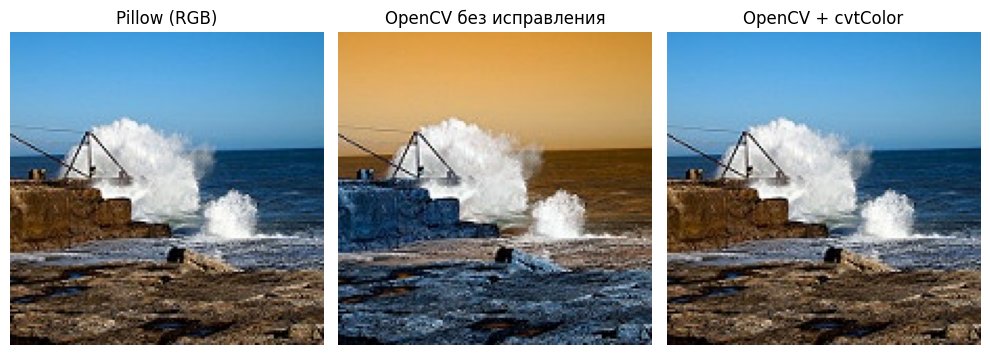

In [26]:
p = lab[(lab.label == 'sea') & ~lab.corrupt].path.iloc[0]
pil = np.array(Image.open(p).convert('RGB'))
bgr = cv2.imread(p)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

print('shape/dtype Pillow:', pil.shape, pil.dtype, '| OpenCV:', bgr.shape, bgr.dtype)
print('пиксель [0,0] Pillow RGB:', pil[0, 0], '| OpenCV BGR:', bgr[0, 0], '| OpenCV после cvtColor:', rgb[0, 0])
print('Pillow == OpenCV без исправления:', np.array_equal(pil, bgr))
print('Pillow == OpenCV после BGR->RGB:', np.array_equal(pil, rgb))

fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
for a, im, t in zip(ax, (pil, bgr, rgb), ('Pillow (RGB)', 'OpenCV без исправления', 'OpenCV + cvtColor')):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## 2. Пайплайн

### 2.1 Очистка и split до аугментаций

Правила:
- `seg_pred` не используется: меток нет.
- `seg_test` остаётся нетронутым финальным тестом.
- Из train убираются повреждённые файлы, изображения, байт-в-байт совпадающие с файлами из test/pred (утечка), группы дубликатов с разными метками (метка неизвестна) и повторные копии внутри train (иначе копия одной картинки окажется и в train, и в validation).
- Split делается один раз, стратифицированно по классам, с фиксированным seed и сохраняется в CSV. Аугментации в split не участвуют: они применяются позже, внутри Dataset, к уже разделённым файлам.

In [27]:
test_hashes = set(df[df.part != 'seg_train'].md5)
tr = df[(df.part == 'seg_train') & ~df.corrupt].copy()
n0 = len(tr)
tr = tr[~tr.md5.isin(test_hashes)]
n1 = len(tr)
tr = tr[tr.dup_labels <= 1]
n2 = len(tr)
tr = tr.drop_duplicates('md5')
print(f'train: {n0} -> убраны пересечения с test/pred: {n0 - n1}, конфликты меток: {n1 - n2}, копии: {n2 - len(tr)} -> осталось {len(tr)}')

class2idx = {c: i for i, c in enumerate(classes)}
tr['y'] = tr.label.map(class2idx)
cols = ['path', 'label', 'y', 'md5']

train_df, val_df = train_test_split(tr[cols], test_size=0.2, stratify=tr.y, random_state=SEED)
train_df, val_df = train_df.sort_values('path').reset_index(drop=True), val_df.sort_values('path').reset_index(drop=True)
test_df = df[(df.part == 'seg_test') & ~df.corrupt].assign(y=lambda d: d.label.map(class2idx))[cols].reset_index(drop=True)

assert not set(train_df.md5) & set(val_df.md5)
assert not set(train_df.md5) & set(test_df.md5)
assert not set(val_df.md5) & set(test_df.md5)

train_df.to_csv(OUT / 'train.csv', index=False)
val_df.to_csv(OUT / 'val.csv', index=False)
test_df.to_csv(OUT / 'test.csv', index=False)

pd.DataFrame({'train': train_df.label.value_counts(), 'val': val_df.label.value_counts(), 'test': test_df.label.value_counts()})

train: 14034 -> убраны пересечения с test/pred: 23, конфликты меток: 20, копии: 5 -> осталось 13986


,train,val,test
label,,,
buildings,1747,437,437
forest,1814,453,474
glacier,1918,480,553
mountain,1997,500,525
sea,1813,453,510
street,1899,475,501


### 2.2 Transforms

Train: случайный кроп с последующим приведением к `IMG_SIZE`, горизонтальное отражение, умеренный `ColorJitter`, перевод в тензор, нормализация.
Validation/test: детерминированные `Resize` до `IMG_SIZE` и нормализация.

### 2.3 Статистики нормализации

Среднее и стандартное отклонение по каналам считаются только по train, на изображениях после того же `Resize`, без аугментаций. Статистики ImageNet выводятся для сравнения: для pretrained-модели нормализовать нужно именно ими, потому что веса обучались на таком распределении входов.

In [28]:
class ImageDS(Dataset):
    def __init__(self, frame, tfm):
        self.paths, self.y, self.tfm = frame.path.tolist(), frame.y.tolist(), tfm

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im:
            img = im.convert('RGB')
        return self.tfm(img), self.y[i]

def stats(frame):
    tfm = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])
    dl = DataLoader(ImageDS(frame, tfm), batch_size=256, num_workers=2)
    s, s2, n = torch.zeros(3), torch.zeros(3), 0
    for x, _ in tqdm(dl):
        s += x.sum((0, 2, 3)); s2 += (x ** 2).sum((0, 2, 3)); n += x.shape[0] * x.shape[2] * x.shape[3]
    mean = s / n
    return mean, (s2 / n - mean ** 2).sqrt()

MEAN, STD = stats(train_df)
IMNET_MEAN, IMNET_STD = torch.tensor([0.485, 0.456, 0.406]), torch.tensor([0.229, 0.224, 0.225])
print('train mean:', MEAN.numpy().round(4), 'std:', STD.numpy().round(4))
print('ImageNet mean:', IMNET_MEAN.numpy(), 'std:', IMNET_STD.numpy())

  0%|          | 0/44 [00:00<?, ?it/s]

train mean: [0.4308 0.4579 0.4544] std: [0.2574 0.256  0.2882]
ImageNet mean: [0.485 0.456 0.406] std: [0.229 0.224 0.225]


In [29]:
def get_transforms(mean, std, size=IMG_SIZE):
    train_tfm = T.Compose([
        T.RandomResizedCrop(size, scale=(0.6, 1.0), ratio=(0.9, 1.1), interpolation=InterpolationMode.BILINEAR, antialias=True),
        T.RandomHorizontalFlip(0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])
    eval_tfm = T.Compose([
        T.Resize((size, size), interpolation=InterpolationMode.BILINEAR, antialias=True),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])
    return train_tfm, eval_tfm

def make_loaders(seed=SEED, mean=MEAN, std=STD, num_workers=2):
    train_tfm, eval_tfm = get_transforms(mean, std)
    g = torch.Generator().manual_seed(seed)
    def worker_init(wid):
        s = torch.initial_seed() % 2 ** 32
        np.random.seed(s); random.seed(s)
    kw = dict(batch_size=BATCH, num_workers=num_workers, worker_init_fn=worker_init, pin_memory=torch.cuda.is_available())
    train_dl = DataLoader(ImageDS(train_df, train_tfm), shuffle=True, drop_last=True, generator=g, **kw)
    val_dl = DataLoader(ImageDS(val_df, eval_tfm), shuffle=False, **kw)
    test_dl = DataLoader(ImageDS(test_df, eval_tfm), shuffle=False, **kw)
    return train_dl, val_dl, test_dl

seed_everything(SEED)
train_dl, val_dl, test_dl = make_loaders()

### 2.4 Проверка батча: shape, dtype, диапазон

In [30]:
for name, dl in (('train', train_dl), ('val', val_dl)):
    x, y = next(iter(dl))
    print(f'{name}: x {tuple(x.shape)} {x.dtype} | y {tuple(y.shape)} {y.dtype}')
    print(f'   range [{x.min():.2f}, {x.max():.2f}] | mean per channel {x.mean((0, 2, 3)).numpy().round(3)} | std {x.std((0, 2, 3)).numpy().round(3)}')
    print('   classes in batch:', torch.bincount(y, minlength=len(classes)).tolist())
    assert x.dtype == torch.float32 and y.dtype == torch.int64 and torch.isfinite(x).all()

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c6f8fe15e40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c6f8fe15e40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

train: x (64, 3, 128, 128) torch.float32 | y (64,) torch.int64
   range [-1.79, 2.21] | mean per channel [0.017 0.027 0.015] | std [0.964 0.965 0.953]
   classes in batch: [10, 10, 10, 12, 14, 8]
val: x (64, 3, 128, 128) torch.float32 | y (64,) torch.int64
   range [-1.79, 2.21] | mean per channel [0.07  0.065 0.125] | std [1.049 1.023 0.987]
   classes in batch: [64, 0, 0, 0, 0, 0]


## 3. Проверка результата

### 3.1 Батчи после обратной нормализации

Обратная нормализация: `x * std + mean`, затем обрезка до [0, 1]. Без неё `imshow` покажет искажённые цвета.

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c6f8fe15e40><function _MultiProcessingDataLoaderIter.__del__ at 0x7c6f8fe15e40>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

      File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
assert self._parent_pid == os.getpid(), 'can only test a

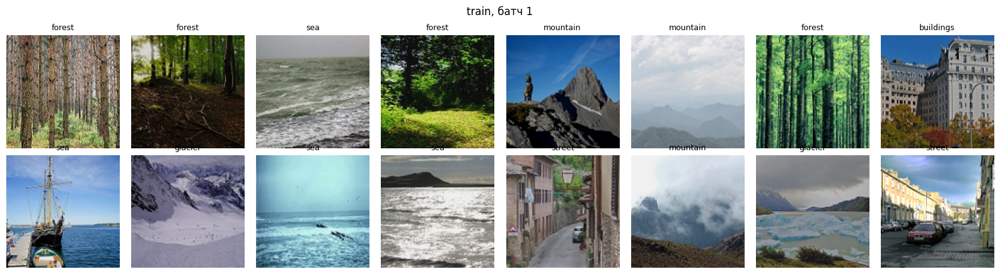

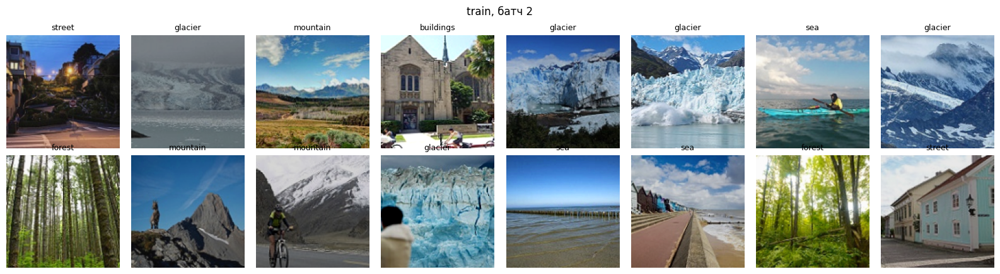

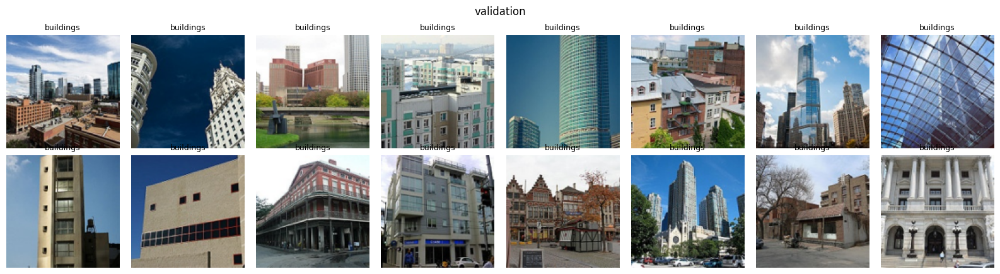

In [31]:
def denorm(x, mean=MEAN, std=STD):
    return (x * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

def show_batch(dl, title, n=16, cols=8):
    x, y = next(iter(dl))
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.2 * rows))
    for a, xi, yi in zip(axes.ravel(), x[:n], y[:n]):
        a.imshow(denorm(xi).permute(1, 2, 0)); a.set_title(classes[yi], fontsize=9); a.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

seed_everything(SEED)
train_dl, val_dl, test_dl = make_loaders()
show_batch(train_dl, 'train, батч 1'); show_batch(train_dl, 'train, батч 2'); show_batch(val_dl, 'validation')

Одна и та же картинка: оригинал и восемь случайных train-аугментаций.

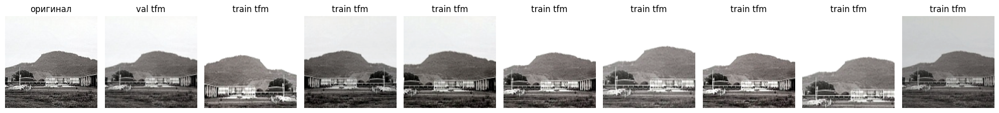

In [32]:
train_tfm, eval_tfm = get_transforms(MEAN, STD)
row = train_df.iloc[0]
img = Image.open(row.path).convert('RGB')
fig, axes = plt.subplots(1, 10, figsize=(20, 2.4))
axes[0].imshow(img); axes[0].set_title('оригинал')
axes[1].imshow(denorm(eval_tfm(img)).permute(1, 2, 0)); axes[1].set_title('val tfm')
for a in axes[2:]:
    a.imshow(denorm(train_tfm(img)).permute(1, 2, 0)); a.set_title('train tfm')
for a in axes: a.axis('off')
plt.tight_layout(); plt.show()

### 3.2 Способы изменения размера

Сравниваем уменьшение 150→40 и увеличение 150→224. Результат уменьшения растягиваем обратно до 150 методом ближайшего соседа, чтобы были видны отдельные пиксели.

Способы: Pillow `NEAREST`, Pillow `BILINEAR` (в Pillow при уменьшении учитывает все исходные пиксели под новым), OpenCV `INTER_LINEAR` (берёт 2×2 соседних пикселя, остальные пропускает), OpenCV `INTER_AREA` (усреднение по площади), Pillow `BICUBIC` и `LANCZOS`.

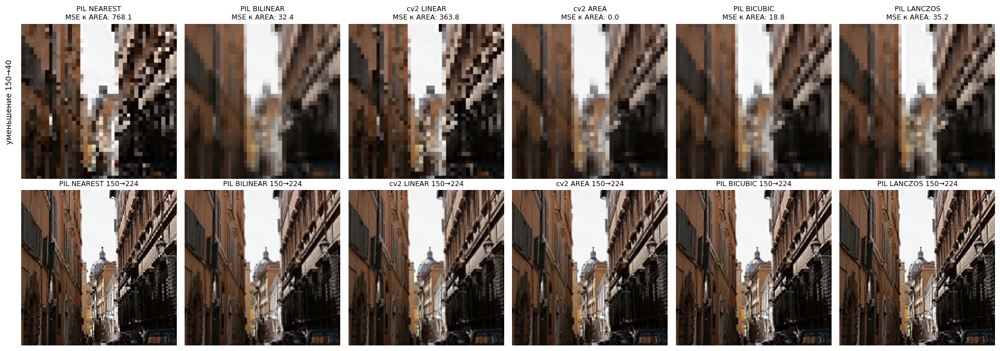

In [33]:
p = lab[(lab.label == 'street') & ~lab.corrupt].path.iloc[3]
src = Image.open(p).convert('RGB')
a = np.array(src)

methods = {
    'PIL NEAREST': lambda s: np.array(src.resize(s, Image.NEAREST)),
    'PIL BILINEAR': lambda s: np.array(src.resize(s, Image.BILINEAR)),
    'cv2 LINEAR': lambda s: cv2.resize(a, s, interpolation=cv2.INTER_LINEAR),
    'cv2 AREA': lambda s: cv2.resize(a, s, interpolation=cv2.INTER_AREA),
    'PIL BICUBIC': lambda s: np.array(src.resize(s, Image.BICUBIC)),
    'PIL LANCZOS': lambda s: np.array(src.resize(s, Image.LANCZOS)),
}

fig, axes = plt.subplots(2, len(methods), figsize=(3 * len(methods), 6.4))
ref_small = methods['cv2 AREA']((40, 40)).astype(float)
for j, (name, f) in enumerate(methods.items()):
    small = f((40, 40))
    axes[0, j].imshow(cv2.resize(small, (150, 150), interpolation=cv2.INTER_NEAREST))
    axes[0, j].set_title(f'{name}\nMSE к AREA: {((small - ref_small) ** 2).mean():.1f}', fontsize=9)
    axes[1, j].imshow(f((224, 224))); axes[1, j].set_title(f'{name} 150→224', fontsize=9)
for ax in axes.ravel(): ax.axis('off')
axes[0, 0].text(-0.05, 0.5, 'уменьшение 150→40', transform=axes[0, 0].transAxes, rotation=90, va='center', ha='right')
plt.tight_layout(); plt.show()


- **`NEAREST`** берёт один пиксель из исходника и отбрасывает остальные. При уменьшении появляется алиасинг: тонкие линии (окна, провода, разметка) рвутся и дают «лесенку» или муар. При увеличении — крупные квадратные блоки.
- **`cv2 LINEAR`** при уменьшении более чем в 2 раза смешивает только 2×2 соседних пикселя и пропускает остальные, поэтому алиасинг близок к `NEAREST`, хотя сам метод «билинейный». Это одна из причин расхождений между пайплайнами на Pillow и OpenCV.
- **`PIL BILINEAR`, `cv2 AREA`** при уменьшении усредняют все исходные пиксели под новым: картинка сглажена, алиасинга почти нет, мелкие детали теряются.
- **`BICUBIC`, `LANCZOS`** сохраняют больше резкости, но вокруг контрастных границ (крыша на фоне неба) возможны светлые и тёмные ореолы (ringing) и выходы значений за диапазон 0–255 до обрезки.
- При увеличении 150→224 новой информации нет: `BILINEAR` даёт размытие, `BICUBIC` и `LANCZOS` — резче, но с ореолами.

Выбор для пайплайна: `Resize` с билинейной интерполяцией и `antialias=True` для train и validation; интерполяция и тип библиотеки (Pillow/OpenCV) должны быть одинаковыми на обучении и в инференсе, иначе модель получит входы из другого распределения.

### 3.3 Воспроизводимость: seed и неизменность validation

Проверки:
1. Split пересчитывается с тем же seed и совпадает с сохранённым.
2. Validation-батчи двух независимых сборок загрузчиков побитово равны.
3. Train-батчи при одинаковом seed равны, при разном — отличаются.
4. Validation-батчи не меняются между вызовами внутри одного процесса (нет случайности в transforms).

In [34]:
_, v2 = train_test_split(tr[cols], test_size=0.2, stratify=tr.y, random_state=SEED)
assert sorted(v2.path) == sorted(val_df.path)
print('1. split воспроизводится')

def first_batches(dl, k=3):
    it = iter(dl)
    return [next(it)[0] for _ in range(k)]

def same(a, b):
    return all(torch.equal(x, y) for x, y in zip(a, b))

seed_everything(SEED); _, va, _ = make_loaders(); v_a = first_batches(va)
seed_everything(SEED); _, vb, _ = make_loaders(); v_b = first_batches(vb)
print('2. validation одинаков между сборками:', same(v_a, v_b))
print('4. validation одинаков при повторном проходе:', same(first_batches(va), first_batches(va)))

seed_everything(SEED); ta, _, _ = make_loaders(SEED); t_a = first_batches(ta)
seed_everything(SEED); tb, _, _ = make_loaders(SEED); t_b = first_batches(tb)
seed_everything(SEED + 1); tc, _, _ = make_loaders(SEED + 1); t_c = first_batches(tc)
print('3. train, тот же seed:', same(t_a, t_b), '| другой seed:', same(t_a, t_c))

1. split воспроизводится
2. validation одинаков между сборками: True
4. validation одинаков при повторном проходе: True
3. train, тот же seed: True | другой seed: False


### 3.4 Допустимые и недопустимые аугментации для этих классов

Классы — сцены, у которых смысл задан расположением областей (небо сверху, земля или вода снизу) и цветом (зелёный лес, голубое море, белый ледник).

| Аугментация | Решение | Причина |
|---|---|---|
| Горизонтальное отражение | допустимо | сцена остаётся той же, зеркальной симметрии «лево-право» у этих классов нет |
| Вертикальное отражение | недопустимо | небо окажется внизу; горизонт моря и склон горы теряют естественную ориентацию, такого снимка в данных нет |
| Поворот на ±10–15° | допустимо с оговоркой | имитирует наклон камеры; большие углы дают пустые углы и меняют ориентацию горизонта |
| Поворот на 90°/180° | недопустимо | то же, что вертикальное отражение |
| Яркость, контраст, насыщенность ±20% | допустимо | имитирует освещение и время суток |
| Сдвиг оттенка (hue) | допустим только очень малый (±0.02) | сильный сдвиг красит лес в красный, море в зелёное, лёд в розовый: класс определяется цветом |
| Перевод в градации серого | осторожно | лес и море частично отличаются цветом; допустимо с малой вероятностью |
| Случайный кроп с масштабом ≥0.6 | допустимо | сохраняет сцену целиком; мелкий кроп (<0.3) может вырезать только небо или только воду, и метка станет ложной |
| Сильное размытие, шум | допустимо слабо | фактура (листва, камни, окна) нужна для различения `forest`/`mountain`, `buildings`/`street` |
| Cutout/random erasing | допустим слабый | большая вырезанная область может убрать единственный признак класса |

Классы `buildings` и `street` пересекаются по содержанию (на улице есть здания), `glacier` и `mountain` — тоже. Агрессивные аугментации, уменьшающие видимую часть сцены, усиливают эту путаницу.

## 4. Вывод: риски утечки и неправильной предобработки

**Утечка данных**
- Дубликаты и пересечения train/test: если не убрать, одна картинка окажется в обучающей и в проверочной выборке, метрика завысится. Хеши проверяются до split и после (`assert`).
- Split делается до аугментаций: если сначала аугментировать, а потом делить, разные версии одной картинки попадут в train и validation.
- Статистики нормализации считаются только по train: среднее и std, посчитанные с validation/test, передают в обучение информацию о проверочных данных. Для pretrained-модели берутся статистики ImageNet — они заданы весами и от данных не зависят.
- `seg_test` не используется для подбора гиперпараметров и ранней остановки; для этого есть validation.
- Одинаковые по смыслу, но не побайтные дубликаты (перекодированные JPEG, соседние кадры) MD5 не находит; остаточный риск оценивается перцептивными хешами или сравнением эмбеддингов.

**Неправильная предобработка**
- BGR вместо RGB при чтении через OpenCV: сеть получает перепутанные каналы.
- Разные интерполяции и библиотеки на обучении и инференсе; `cv2 LINEAR` при сильном уменьшении даёт алиасинг, которого нет у Pillow.
- Случайные операции в validation transforms: метрика шумит от запуска к запуску.
- Забытая обратная нормализация при визуализации и нормализация не теми статистиками (на 0–255 вместо 0–1, или ImageNet-статистики при обучении с нуля на другом распределении).
- Не зафиксированы seed и `worker_init_fn`: порядок батчей и аугментации различаются между запусками.
- Агрессивные геометрические и цветовые аугментации меняют метку (см. таблицу выше).